# Task 2: EfficientNet-B0

This notebook loads Notebook 1's prepared arrays and trains only EfficientNet-B0. Shared neural-network
augmentation, batching, checkpointing, recovery, and evaluation live in `src/task2_utils.py`.


## How to Run

Run `01_task2_setup.ipynb` first. Change the settings below if needed, then run this notebook.
It does not rerun setup or another model.


## 1. Setup


In [1]:
%matplotlib inline
import torch.nn as nn
from IPython.display import display


In [2]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "pyproject.toml").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the repository root containing pyproject.toml")
sys.path.insert(0, str(REPO_ROOT))

from torchvision.models import efficientnet_b0
from src.task2_utils import (
    NeuralTrainer, ensure_task2_directories, model_checkpoint_path,
    neural_training_config, prepared_namespace, result_frame,
)
ensure_task2_directories()


### 1.1 Training configuration


In [3]:
QUICK_RUN = False
RANDOM_STATE = 42
RESUME = False
ALLOW_CPU = False

TRAINING_CONFIG = neural_training_config(
    quick_run=QUICK_RUN, random_state=RANDOM_STATE, resume=RESUME, allow_cpu=ALLOW_CPU,
)
MODEL_CONFIG = {"architecture": "efficientnet_b0", **{
    key: value for key, value in TRAINING_CONFIG.items()
    if key not in {"resume", "allow_cpu", "keep_epoch_checkpoints"}
}}

## 2. Load Prepared Data and Shared Training Pipeline


In [4]:
data = prepared_namespace()
assert data.config.get("quick_run") == QUICK_RUN, (
    "QUICK_RUN does not match Notebook 1's prepared cache. "
    "Set the same value in both notebooks and rerun Notebook 1 if needed."
)
trainer = NeuralTrainer(data, TRAINING_CONFIG)
print(f"Loaded {len(data.train_frame):,} train and {len(data.validation_frame):,} validation rows")
print(f"Training batches per epoch: {len(trainer.train_loader)}")


Apple Metal GPU detected; using the PyTorch MPS backend.
Device: mps | mixed precision: False | run fingerprint: 5f507c7bb57f
Loaded 30,260 train and 7,566 validation rows
Training batches per epoch: 237


## 3. Train EfficientNet-B0


EfficientNet-B0: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_efficientnet_b0.pt has an incompatible run fingerprint; training a compatible checkpoint
[EfficientNet-B0] starting epoch 1/30 (237 train + 15 validation batches)
[EfficientNet-B0] finished epoch 1/30 | train loss 1.1344 | val loss 1.0553 | val accuracy 0.5521 | macro-F1 0.3789 | best 0.3789 (epoch 1) | lr 6.67e-04 | 64s
[EfficientNet-B0] starting epoch 2/30 (237 train + 15 validation batches)
[EfficientNet-B0] finished epoch 2/30 | train loss 1.0035 | val loss 0.9378 | val accuracy 0.6191 | macro-F1 0.5573 | best 0.5573 (epoch 2) | lr 1.00e-03 | 61s
[EfficientNet-B0] starting epoch 3/30 (237 train + 15 validation batches)
[EfficientNet-B0] finished epoch 3/30 | train loss 0.9455 | val loss 0.9040 | val accuracy 0.6484 | macro-F1 0.6103 | best 0.6103 (epoch 3) | lr 1.00e-03 | 61s
[EfficientNet-B0] starting epoch 4/30 (237 train + 15 validation batches)
[EfficientNet-B0] finished epoch 4/30 | t

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,EfficientNet-B0,0.756278,0.750981,0.720965,0.755252,0.944224


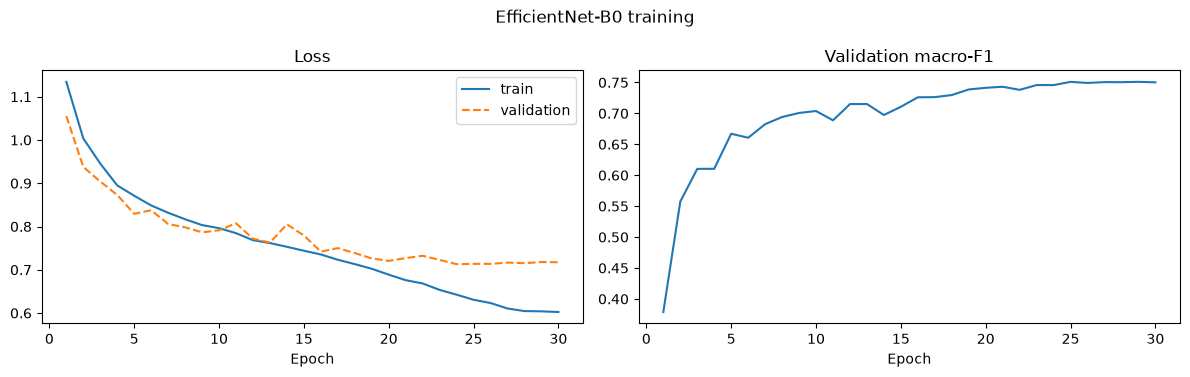

In [5]:
def build_model():
    model = efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, data.n_classes)
    return model

efficientnet, history, logits = trainer.train_or_restore(
    "efficientnet_b0", build_model, "EfficientNet-B0", MODEL_CONFIG
)
predictions = logits.argmax(axis=1)
display(result_frame(data.y_val, predictions, logits, "EfficientNet-B0"))
trainer.plot_history(history, "EfficientNet-B0 training")


## 4. Export EfficientNet-B0 Results


In [6]:
print("Completed checkpoint:", model_checkpoint_path("efficientnet_b0"))
print("Run fingerprint:", data.fingerprint)


Completed checkpoint: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_efficientnet_b0.pt
Run fingerprint: 5f507c7bb57f
